## Michael Madden, Jan 2026
Simple Python notebook to read and plot small datasets for assignment.

In [1]:
# Package imports
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import sklearn.datasets
import pandas as pd
import numpy as np

In [2]:
# Display plots inline
%matplotlib inline

## Task 1 - Logistic Reg

In [15]:
#https://www.youtube.com/watch?v=S6iuhdYsGC8

import numpy as np

def sigmoid(z):
    return 1.0/(1.0 + np.exp(-z))

def calculate_grdient(theta, X_b, y):
    m = y.size #number of instances
    y_hat = sigmoid(X_b @ theta)
    gradient = (1 / m) * (X_b.T @ (y_hat - y)) #@ is matrix multiplication
    return gradient 

def gradient_descent(X, y, alpha=0.1, num_iter=100, tol=1e-7):
    X_b = np.c_[np.ones((X.shape[0], 1)),X]
    theta = np.zeros(X_b.shape[1])
    for i in range(num_iter):
        grad = calculate_grdient(theta, X_b, y)
        theta -= alpha * grad
        if np.linalg.norm(grad) < tol:
            break
    return theta

def predict_proba(X, theta):
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    return sigmoid(X_b @ theta)

def predict(X, theta, threshold=0.5):
    return (predict_proba(X,theta) >= threshold).astype(int)

## Dataset 1 - Blobs 3D

In [4]:
# Use pandas to read the CSV file as a dataframe
df1 = pd.read_csv("blobs600.csv")

# The y values are those labelled 'Class': extract their values
y1 = df1['Class'].values

# The x values are all other columns
del df1['Class']   # drop the 'Class' column from the dataframe
X1 = df1.values     # convert the remaining columns to a numpy array

In [5]:
# Check its dimensions

print(f"The dimensions of the dataset are: {np.shape(X1)}")

The dimensions of the dataset are: (600, 3)


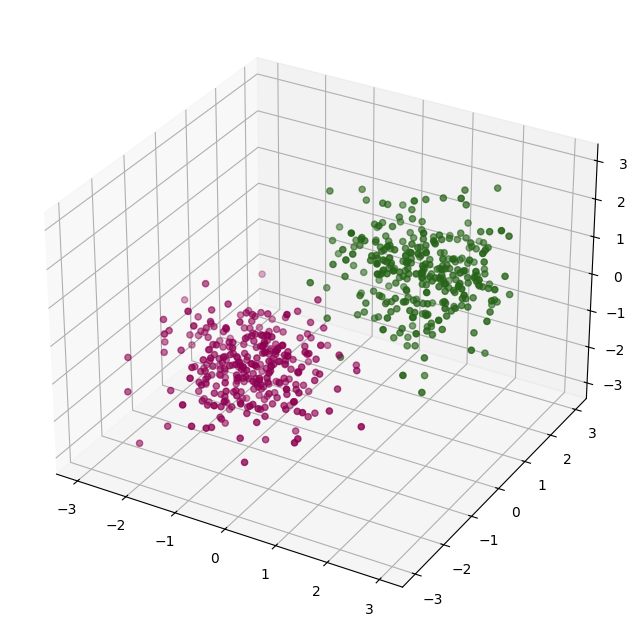

In [6]:
# Plot the dataset in 3D, with colours according to the class label

fig = plt.figure(figsize=(8, 8)) # set the size to 8x8 
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X1[:,0], X1[:,1], X1[:,2], c=y1, cmap="PiYG") # changed the colour map because why not

plt.show()
plt.close(fig)

## Dataset 2 - Circles 2D

In [7]:
# Use pandas to read the CSV file as a dataframe
df2 = pd.read_csv("circles500.csv")

# The y values are those labelled 'Class': extract their values
y2 = df2['Class'].values

# The x values are all other columns
del df2['Class']   # drop the 'Class' column from the dataframe
X2 = df2.values     # convert the remaining columns to a numpy array

In [8]:
# Check its dimensions

print(f"The dimensions of Dataset 2 are: {np.shape(X2)}")

The dimensions of Dataset 2 are: (500, 2)


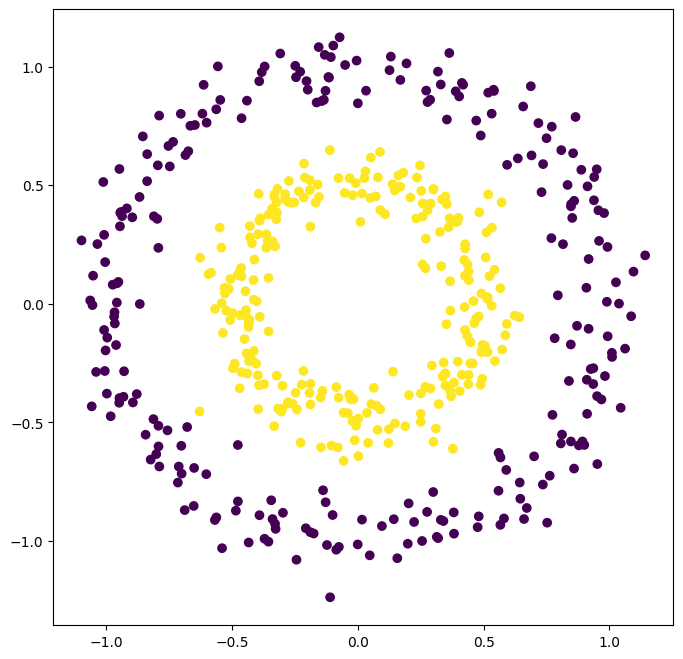

In [9]:
# plot X[0] vs X[1] and colour points according to the class, y

fig, ax = plt.subplots(figsize=(8, 8)) 

ax.scatter(X2[:,0], X2[:,1], c=y2) 

plt.show()
plt.close(fig)

## Examine Data

In [10]:
# Some examples of working with the data, to look at rows/columns
print ("len(X2):", len(X2))            # outer array: one per sample
print ("len(X2[0]):", len(X2[0]))      # each inner array is the attributes of one sample
print ("len(X2[:,0]):", len(X2[:,0]))  # select column 0 from array

# np.shape returns all dimensions of the array
(nsamples, nattribs) = np.shape(X2)
print ("X2: nsamples =", nsamples, ", nattribs =", nattribs)

# Now example the y vector (1D array)
print ("len(y2)", len(y2))
print ("np.shape(y2):", np.shape(y2))

# You can transpose the y data using 'reshape'
yt = np.reshape(y2, (len(y2),1))  
print ("np.shape(yt):", np.shape(yt))
(nsamples, nattribs) = np.shape(yt)
print ("y2 transpose: nsamples =", nsamples, ", nattribs =", nattribs)

len(X2): 500
len(X2[0]): 2
len(X2[:,0]): 500
X2: nsamples = 500 , nattribs = 2
len(y2) 500
np.shape(y2): (500,)
np.shape(yt): (500, 1)
y2 transpose: nsamples = 500 , nattribs = 1


## Task 2 Testing

In [11]:
def split_dataset(X, y, train_ratio=0.7, val_ratio=0.15, seed=42):
    np.random.seed(seed)
    m = X.shape[0]
    indices = np.random.permutation(m)

    train_end = int(train_ratio * m)
    val_end = int((train_ratio + val_ratio) * m)

    train_idx = indices[:train_end]
    val_idx = indices[train_end:val_end]
    test_idx = indices[val_end:]

    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    return X_train, y_train, X_val, y_val, X_test, y_test

In [12]:
# Dataset 1 (3D, blobs)
X1_train, y1_train, X1_val, y1_val, X1_test, y1_test = split_dataset(X1, y1)

# Dataset 2 (2D, circles)
X2_train, y2_train, X2_val, y2_val, X2_test, y2_test = split_dataset(X2, y2)


In [13]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


In [16]:
learning_rates = [0.001, 0.01, 0.1, 0.5]

best_lr_1 = None
best_acc_1 = 0

for lr in learning_rates:
    theta = gradient_descent(X1_train, y1_train, alpha=lr)
    preds = predict(X1_val, theta)
    acc = accuracy(y1_val, preds)

    if acc > best_acc_1:
        best_acc_1 = acc
        best_lr_1 = lr

print("Dataset 1 best learning rate:", best_lr_1)


Dataset 1 best learning rate: 0.001


In [17]:
best_lr_2 = None
best_acc_2 = 0

for lr in learning_rates:
    theta = gradient_descent(X2_train, y2_train, alpha=lr)
    preds = predict(X2_val, theta)
    acc = accuracy(y2_val, preds)

    if acc > best_acc_2:
        best_acc_2 = acc
        best_lr_2 = lr

print("Dataset 2 best learning rate:", best_lr_2)


Dataset 2 best learning rate: 0.1


In [18]:
# Dataset 1
theta1 = gradient_descent(X1_train, y1_train, alpha=best_lr_1)
test_preds_1 = predict(X1_test, theta1)
test_acc_1 = accuracy(y1_test, test_preds_1)

print("Dataset 1 Test Accuracy:", test_acc_1)


Dataset 1 Test Accuracy: 1.0


In [19]:
# Dataset 2
theta2 = gradient_descent(X2_train, y2_train, alpha=best_lr_2)
test_preds_2 = predict(X2_test, theta2)
test_acc_2 = accuracy(y2_test, test_preds_2)

print("Dataset 2 Test Accuracy:", test_acc_2)


Dataset 2 Test Accuracy: 0.5733333333333334


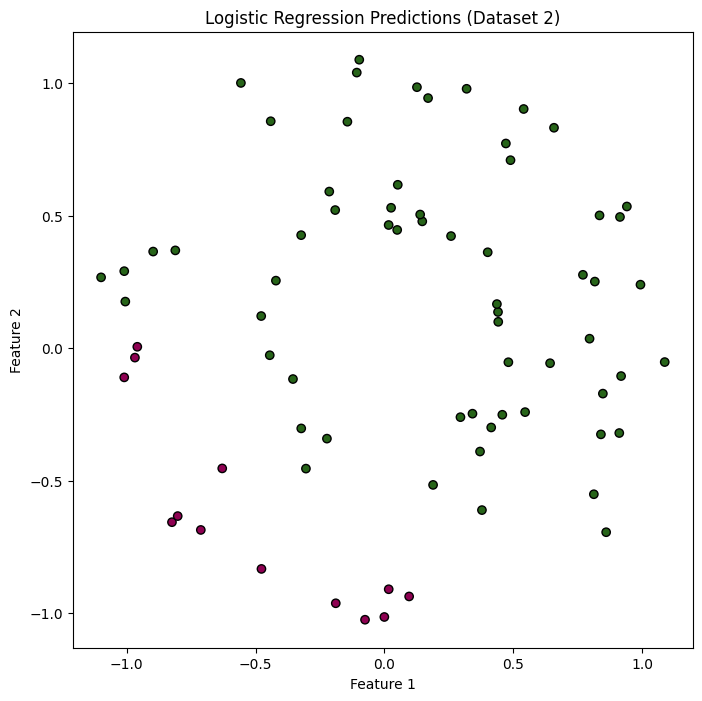

In [20]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    X2_test[:, 0],
    X2_test[:, 1],
    c=test_preds_2,
    cmap="PiYG",
    edgecolors="k"
)

ax.set_title("Logistic Regression Predictions (Dataset 2)")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")

plt.show()


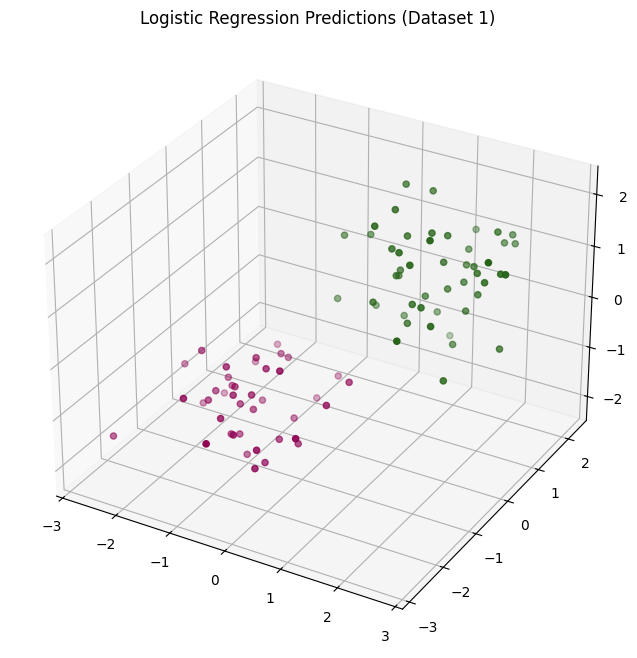

In [ ]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X1_test[:, 0],
    X1_test[:, 1],
    X1_test[:, 2],
    c=test_preds_1,
    cmap="PiYG"
)

ax.set_title("Logistic Regression Predictions (Dataset 1 - blobs)")

plt.show()
